## Neural Networks and Deep Learning Project

The goal of the project is to re-implement a famous Convolutionnal Architecture from scratch to showcase the resnet architecture against conventionnal convolution architecture.

### 0. Importing the libraries

In [1]:
from fastai.vision.all import *
import torch
import torch.nn as nn
from torch import tensor
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import csv
import os
import pandas as pd

In [2]:
configs = {
    18 : [2, 2, 2, 2],
    34 : [3, 4, 6, 3],
    50 : [3, 4, 6, 3],
    101: [3, 4, 23, 3],
    152: [3, 8, 36, 3]
}
#Sizes of the differents layers with different sizes

In [3]:
#For the classes, since i am working with Imagenette 160 I implemented a dictionnary to see the class that corresponds to the number (it won't work with another dataset)
id_to_english = {
    "n01440764": "Tench",
    "n02102040": "English springer",
    "n02979186": "Cassette player",
    "n03000684": "Chain saw",
    "n03028079": "Church",
    "n03394916": "French horn",
    "n03417042": "Garbage truck",
    "n03425413": "Gas pump",
    "n03445777": "Golf ball",
    "n03888257": "Parachute"
}
def get_name_from_id(class_id):
    """Return the classe's name if found in the dictionnary """
    return id_to_english.get(class_id, f"Unknown ({class_id})")

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


### 1.1 Loading the dataset
Before working on our model, we will start by loading the dataset from Imagenette using FASTAI for the loading and data-augmentation.

In [ ]:
def get_data(url, presize, resize):
    path = untar_data(url)
    return DataBlock(
        blocks=(ImageBlock, CategoryBlock), get_items=get_image_files,
        splitter=GrandparentSplitter(valid_name='val'),
        get_y=parent_label, item_tfms=Resize(presize),
        batch_tfms=[*aug_transforms(min_scale=0.5, size=resize),
                    Normalize.from_stats(*imagenet_stats)],
    ).dataloaders(path, bs=32)
    #The batch size is reduced when working on deeper models

dls = get_data(URLs.IMAGENETTE_320, 320, 224) #128 avant


In [6]:
x, y = dls.one_batch()
print(x.shape)
print(f"Number of classes : {dls.c}")

torch.Size([32, 3, 224, 224])
Number of classes : 10


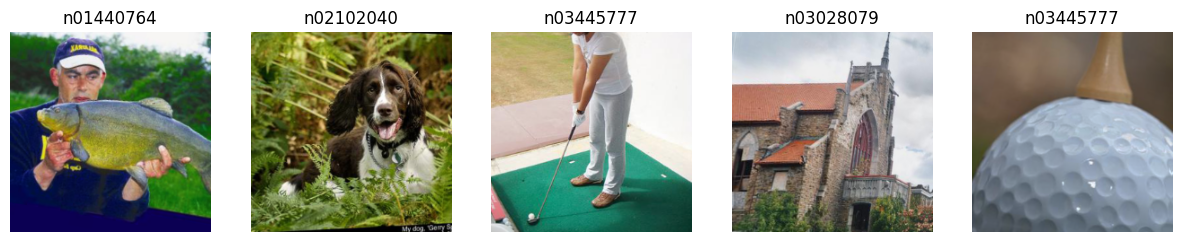

In [7]:
dls.show_batch(nrows=1, ncols=5)

The data is loaded, for now the batch size is 128 or 32, the image dimension is resized to 224x224 and the color canal is RGB.

About the dataset itself, Imagenette 160/320 is a subset of Imagenette with only 10 different classes, the classe's ID format prevent confusion (when there is an homonym).

### 2.1 Building the architecture

According to Deep Residual Learning for Image Recognition, the resnet is made by alternating convolution and batch transformation. We will use the same structure than TP7.

In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, useBn = True):
      super().__init__()

      self.relu = nn.ReLU(inplace=True) #Will consume less space

      if not useBn :
        self.bn1 = nn.Identity()
        self.bn2 = nn.Identity()

      else :
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

      self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
      self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)

      if stride == 2 or in_channels != out_channels :
        if not useBn : 
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else :
          self.shortcut = nn.Sequential(
              OrderedDict([
              ("conv_shortcut", nn.Conv2d(in_channels, out_channels, 1, stride)),
              ("batch_norm_shortcut", nn.BatchNorm2d(out_channels)),
          ]))
      else :
        self.shortcut = nn.Sequential() #When there is no parameters it won't change anything (no changes on x)


    def forward(self, x) :
      s = self.shortcut(x)

      x = self.conv1(x)
      x = self.bn1(x)

      x = self.relu(x)

      x = self.conv2(x)
      x = self.bn2(x)

      return self.relu(x + s)

In [9]:
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, stride, useBn = True):
      super().__init__()

      self.relu = nn.ReLU(inplace=True) #Will consume less space
      mid_channels = out_channels // 4

      self.conv1 = nn.Conv2d(in_channels, mid_channels, 1)
      self.bn1 = nn.BatchNorm2d(mid_channels)

      self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3, stride=stride, padding=1)
      self.bn2 = nn.BatchNorm2d(mid_channels)
      
      self.conv3 = nn.Conv2d(mid_channels, out_channels, 1)
      self.bn3 = nn.BatchNorm2d(out_channels)

      if stride == 2 or in_channels != out_channels :
        if not useBn : 
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride)
        else :
          self.shortcut = nn.Sequential(
              OrderedDict([
              ("conv_shortcut", nn.Conv2d(in_channels, out_channels, 1, stride)),
              ("batch_norm_shortcut", nn.BatchNorm2d(out_channels)),
          ]))
      else :
        self.shortcut = nn.Sequential() #When there is no parameters it won't change anything (no changes on x)


    def forward(self, x) :
      s = self.shortcut(x)

      x = self.conv1(x)
      x = self.bn1(x)

      x = self.relu(x)

      x = self.conv2(x)
      x = self.bn2(x)

      x = self.relu(x)

      x = self.conv3(x)
      x = self.bn3(x)

      return self.relu(x + s)

In [ ]:
class ResNet(nn.Module):
    def __init__(self, size, in_channels, useBn = True, fc = False):
      super().__init__()

      if size not in configs :
        raise ValueError("This resnet's size is not valid")

      if size >= 50:
          block = Bottleneck
          self.expansion = 4
      else:
          block = ResBlock 
          self.expansion = 1

      self.use_fc = fc

      self.relu = nn.ReLU(inplace=True) #Will consume less space aussi

      self.conv1 = nn.Conv2d(in_channels, 64, 7, 2, padding=3)
      
      if not useBn :
        self.bn1 = nn.Identity()
      else : 
        self.bn1 = nn.BatchNorm2d(64)

      self.maxPool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

      self.in_channel = 64
      
      #Après le stem, les in_channels sont toujours 64

      #Maintenant on initialise les layers

      self.layer1 = self._make_layer(block, 64 * self.expansion, configs[size][0], 1, useBn=useBn)
      self.layer2 = self._make_layer(block, 128 * self.expansion, configs[size][1], 2, useBn=useBn)
      self.layer3 = self._make_layer(block, 256 * self.expansion, configs[size][2], 2, useBn=useBn)
      self.layer4 = self._make_layer(block, 512 * self.expansion, configs[size][3], 2, useBn=useBn)

      self.avgPool = nn.AvgPool2d(kernel_size = 7) # I thin i can use adaptative pool but i will see later
      self.fc = nn.Linear(512 * self.expansion, 10) #10 = nombre de classes d'imagenette

      if self.use_fc :
        self.fc = nn.Conv2d(512 * self.expansion, 10, kernel_size=1)

    def _make_layer(self, block, out_channel, n, stride = 1, useBn = True):
      #Je mets block pour pouvoir mettre un resblock ou un bottle neck
      layers = []

      for i in range(n) :
        if i == 0 :
          #If this is the first block of the layer, we need to reduce the dimension
          layers.append(block(self.in_channel, out_channel, stride, useBn))
          self.in_channel = out_channel
          #Pour que si on a diviser par 2 avec la stride ça marche bien
        else :
          layers.append(block(self.in_channel, out_channel, 1, useBn))

      return nn.Sequential(*layers)

    def forward(self, x) :

        x = self.conv1(x)
        x = self.bn1(x) #If batch norm is deactivated, it will act as a *1 multiplication
        x = self.relu(x)
        x = self.maxPool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgPool(x)
        if self.use_fc :
          x = self.fc(x)
          x = torch.flatten(x, 1)
        else :
          #Flatten pour passer de batchx512x1x1 à batchx512
          x = self.fc(torch.flatten(x, 1,3))

        return x

### Basic Testing

In [11]:
tenseurTest = torch.randn((12, 3, 224, 224))
resnet = ResNet(34, 3)
output = resnet(tenseurTest)
print(output.shape)

torch.Size([12, 10])


In [ ]:
def trainingModel(modele, dls, nbEpoch = 10, lr = 0.01, optimiser = "SGD", label_smoothing = 0.0, use_mixeup = False, alpha = 0.0, save_csv = None) :
  """ 
  modele : the modele (here for now always a resnet)
  dls : The data where our modele will train 
  nbEpoch : the number of epochs, by default 10 but i train 100 epochs
  lr : the learning rate of the optimizer
  optimiser : The optimiser for reducing the loss either sgd or adam for nom
  label smoothing : the value of epsilon (see formula below) for label smoothing
  use_mixeup : Boolean indicatinf if data mix up augmentation will be used
  alpha : Probabilistic parameters for the data mix up augmentation
  alpha : parameters dictating the repartition of proportion of classes, alpha = 1.0 mean as much 50/50 images than 90/10
  """
  device = torch.device('cuda')
  modele = modele.to(device)

  if optimiser == "adam" :
    print("Using Adam")
    optimizer = torch.optim.Adam(modele.parameters(), lr = lr)
  else :
    optimizer = torch.optim.SGD(modele.parameters(), lr=lr, momentum = 0.9)
  #Sans momentum, l'accuracy oscille pas mal, du coup, plutôt que de manuellement tester les lr, je vais ajouter du momentum
  criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing) #By defaul it is 0.0

  if save_csv:
        with open(save_csv, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Epoch', 'Train_Loss', 'Val_Accuracy'])

  for i in range(nbEpoch) :
    modele.train()
    lossMoy = 0

    for x,y in dls.train :

      x = torch.tensor(x).to(device)
      y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU

      if use_mixeup :

        lambd = np.random.beta(alpha, alpha) #Using beta as mentionned in the article

        batch_size = x.size(0) #Using dls.bs may cause out of bound error if the number of image is not modulo bs

        index = torch.randperm(batch_size).to(device) # Creating a list of index from 0 to the size of the batch

        mixed_x = lambd * x + (1 - lambd) * x[index] #We create the batch with mixed data where the picture at the base index and the random are multiplied by lambda and 1-lambda 

        predictions = modele(mixed_x) # We get the prediction for those mixed up datas

        loss = lambd * criterion(predictions, y) + (1 - lambd) * criterion(predictions, y[index]) # We do the same as x but for y to get the good precision

      else :
        
        optimizer.zero_grad()

        predictions = modele(x)

        loss = criterion(predictions, y)

      #In both case i do the back propagation
      lossMoy += loss.item()

      loss.backward()

      optimizer.step()

  #Pour calculer l'accuracy à la fin de chaque epoch
    modele.eval()
    total_correct = 0
    with torch.no_grad():
      for x,y in dls.valid :
        x = torch.tensor(x).to(device)
        y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
        prediction_acc = modele(x)

        predictedClass = torch.argmax(prediction_acc, dim=1)

        correct = (predictedClass == y)

        total_correct += torch.sum(correct)

    train_loss = lossMoy/len(dls.train)
    valid_acc = (total_correct/len(dls.valid.dataset)).item()
    print(f"Epoch n°{i+1}, loss = {train_loss}, accuracy = {valid_acc}")

    if save_csv:
            with open(save_csv, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([i + 1, train_loss, valid_acc])


In [ ]:
#I took different picture on google image and tried to apply it to my model.
def TestImage(monResnet, image = "Test_Golf.png") :
    
    img_pil = Image.open(image).convert('RGB')

    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img_pil).unsqueeze(0).to(torch.device('cuda'))

    monResnet.eval()
    with torch.no_grad():
        logits = monResnet(img_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1)

    score_max, index_max = torch.max(probs, 1)
    print(probs)
    confiance = score_max.item() * 100

    raw_id = dls.vocab[index_max.item()]
    real_name = get_name_from_id(raw_id)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.axis('off')
    plt.title(f"{real_name}\n Certainty : {confiance:.2f}%")
    plt.show()

#### Little test to see if everything is working fine

In [14]:
model = ResNet(size=50, in_channels=3)

dummy_input = torch.randn(2, 3, 224, 224)

output = model(dummy_input)

print(output.shape) 

torch.Size([2, 10])


Function to get the drop and other infos

In [15]:
def get_model_metrics(csv_filename):

    df = pd.read_csv(csv_filename)
    
    df.columns = df.columns.str.strip()
    
    max_acc = df['Val_Accuracy'].max()
    last_acc = df['Val_Accuracy'].iloc[-1]
    last_loss = df['Train_Loss'].iloc[-1]

    drop = max_acc - last_acc
    
    return {
        "max_acc": max_acc,
        "last_acc": last_acc,
        "last_loss": last_loss,
        "drop": drop
    }

### Label smoothing

It consist in "smoothing" the result, basically, when we take a picture its labels are [0,0,0,1] where the 1 indicates its class.

When using label smoothing, we change the label's value using a factor $\epsilon$ where the distribution looks like [ $\frac{\epsilon}{K}$, $\frac{\epsilon}{K}$, $\frac{\epsilon}{K}$, $(1-\epsilon) + \frac{\epsilon}{K}$ ] with K the number of classes.

It changes the target, the optimal logit become a finite value $ z^*_y = \log\left(\frac{(K-1)(1-\epsilon)}{\epsilon}\right) + \alpha $, making it so that our model doesn't push it's weight to infinity, reducing overfitting.


### Mixup data augmentation 

Similar to label smoothing but now we "fuse" two images and the label become the proportion of the image [0,0,0.4,0.6] for example.

However, applying both label smoothing and mixup data augmentation may cause over-smoothing.

### Bottle neck layer

It allows us to reduce the quantity of operations and parameters.

For example, with 256 channels :

We reduce it (here it is by 4) with a conv 1x1, so know we have 64 channels

We apply the 3x3 Conv (which is the biggest operation)

We use another conv 1x1 to bring it back to 256

Doing this allows us to have $ 64 \times 64 \times 3 \times 3 $ operations instead of $ 256 \times 256 \times 3 \times 3 $ For the big convolution part.

### Fully Convolutionnal vs Fully Connected on top

Implemented but not used 

# Experimentation  
(I will write my results for different parameters)

Also, since the dataset in balanced and there is no hierarchy between classes, i consider that accuracy is a great metric to show the model's performance

### Another Test

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\

Epoch n°1, loss = 2.116264714224864, accuracy = 0.3070063591003418
Epoch n°2, loss = 1.7007698152024868, accuracy = 0.4540127217769623
Epoch n°3, loss = 1.4689634454452385, accuracy = 0.5464968085289001
Epoch n°4, loss = 1.3341302542363183, accuracy = 0.5656050443649292
Epoch n°5, loss = 1.218160367012024, accuracy = 0.6061146259307861
Epoch n°6, loss = 1.1202996654025579, accuracy = 0.6461145877838135
Epoch n°7, loss = 1.045523306676897, accuracy = 0.6731209754943848
Epoch n°8, loss = 0.9881384892989014, accuracy = 0.6272611021995544
Epoch n°9, loss = 0.932054229206958, accuracy = 0.7024203538894653
Epoch n°10, loss = 0.917706493705006, accuracy = 0.7248407006263733
Epoch n°11, loss = 0.8726319897983034, accuracy = 0.7016559839248657
Epoch n°12, loss = 0.8525291907585273, accuracy = 0.7154139876365662
Epoch n°13, loss = 0.788028890702684, accuracy = 0.7640764117240906
Epoch n°14, loss = 0.7885981458728596, accuracy = 0.7291719317436218
Epoch n°15, loss = 0.785313570853007, accuracy = 

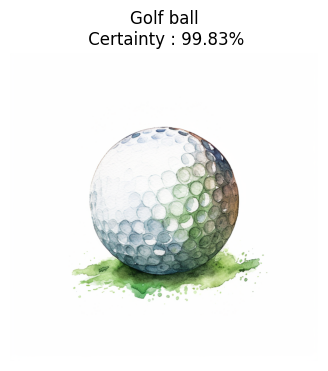

In [16]:
monResnet = ResNet(50, 3, useBn=True).to(torch.device('cuda'))

trainingModel(monResnet, dls, 100, 0.001, optimiser="adam", save_csv="Adam_Resnet50_lr0.001.csv")

TestImage(monResnet)

In [19]:
monResnet = ResNet(34, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.01, optimiser="sgd", save_csv="SGD_Resnet34_lr0.01.csv")

C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\2239335680.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_20928\

Epoch n°1, loss = 2.064072357597998, accuracy = 0.32968151569366455
Epoch n°2, loss = 1.6309313966056047, accuracy = 0.5256050825119019
Epoch n°3, loss = 1.3582366599874982, accuracy = 0.6107006072998047
Epoch n°4, loss = 1.2176778047771777, accuracy = 0.6078980565071106
Epoch n°5, loss = 1.113159785230281, accuracy = 0.6805095076560974
Epoch n°6, loss = 1.005089746289334, accuracy = 0.7238216400146484
Epoch n°7, loss = 0.9357199844667468, accuracy = 0.6957961320877075
Epoch n°8, loss = 0.8704369733899326, accuracy = 0.6947770118713379
Epoch n°9, loss = 0.8115757531028683, accuracy = 0.7021655440330505
Epoch n°10, loss = 0.7616613722453683, accuracy = 0.7668789625167847
Epoch n°11, loss = 0.7585541432186709, accuracy = 0.7847133278846741
Epoch n°12, loss = 0.6921873724056502, accuracy = 0.7829298973083496
Epoch n°13, loss = 0.6645176217212515, accuracy = 0.7872611284255981
Epoch n°14, loss = 0.6484306212198936, accuracy = 0.7949044108390808
Epoch n°15, loss = 0.6076521927017277, accura

## Plotting performances 

### On Imagenette 160

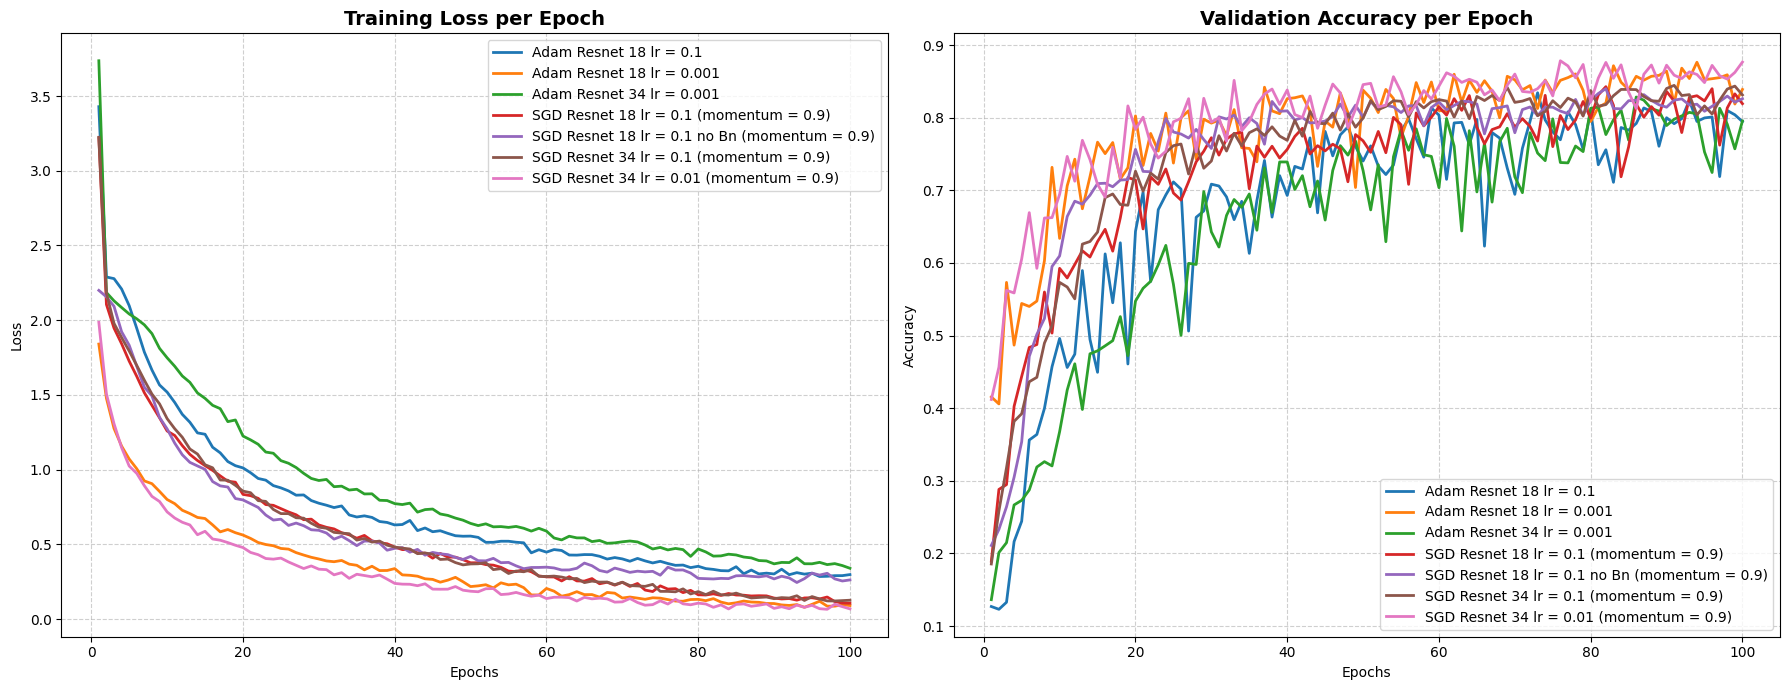

In [17]:

files_map = {
    "Imagenette160\Adam_Resnet18_lr0.1.csv":"Adam Resnet 18 lr = 0.1",
    "Imagenette160\Adam_Resnet18_lr0.001.csv":"Adam Resnet 18 lr = 0.001",
    "Imagenette160\Adam_Resnet34_lr0.001.csv" : "Adam Resnet 34 lr = 0.001",
    "Imagenette160\SGD_Resnet18_moentum09_lr0.1.csv": "SGD Resnet 18 lr = 0.1 (momentum = 0.9)",
    "Imagenette160\SGD_Resnet18_moentum09_lr0.1NOBN.csv": "SGD Resnet 18 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette160\SGD_Resnet34_moentum09_lr0.1.csv": "SGD Resnet 34 lr = 0.1 (momentum = 0.9)",
    "Imagenette160\SGD_Resnet34_moentum09_lr0.01.csv": "SGD Resnet 34 lr = 0.01 (momentum = 0.9)"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, (filename, label) in enumerate(files_map.items()):

    df = pd.read_csv(filename)

    color = colors[i % len(colors)]
    
    # Traçage de la Loss
    # On gère le cas où la loss est NaN (pour NOBN) pour que ça ne casse pas le graphe
    ax1.plot(df['Epoch'], df['Train_Loss'], label=label, color=color, linewidth=2)
    
    # Traçage de l'Accuracy
    ax2.plot(df['Epoch'], df['Val_Accuracy'], label=label, color=color, linewidth=2)
    
ax1.set_title('Training Loss per Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.set_title('Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('comparaison_performance_resnet_160.png') 
plt.show()

# Analysis of the performance of my different models

### 1. Performance's Ranking

To make sure a model isn't just lucky i added a drop value that represent the difference between its max accuracy and its last one (if during epoch 80 it had a great but lucky score its drop will be high), the Drop formula is simply $ Max(Accuracy) - Last Accuracy$.

| Modèle | Optimiseur | LR | Max Acc (Peak) | Final Acc | Final Loss | Drop |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | 
| ResNet34 | SGD (Momentum) | 0.01 | 87.85% | 87.67% | 0.068 | 0.18% |
| ResNet18 | Adam | 0.001 | 87.64% | 83.90% | 0.091 | 3.75% |
| ResNet34 | SGD (Momentum) | 0.1 | 84.46% | 83.13% | 0.126 | 1.32% |
| ResNet18 | SGD (Momentum) | 0.1 | 84.28% | 81.94% | 0.106 | 2.34% |
| ResNet18 | SGD (NO BN) | 0.1 | 84.00% | 82.62% | 0.262 | 1.38% |
| ResNet18 | Adam | 0.1 | 83.44% | 79.46% | 0.298 | 3.97% |
| ResNet34 | Adam | 0.001 | 82.85% | 79.57% | 0.340 | 3.29% |

---

### 2. Interpretation

#### A. Learning Rate (Adam)

Especially for Adam, the learning rate is too high at 0.1, with resnet 18 the learning rate is way better at `0.001` than `0.1`, it makes sense because Adam is an adaptative learning rate (instead of SGD) and if the starting learning rate is too high it won't be able to converge into the global minimum.

#### B. SGD vs Adam
* For **ResNet18** : Adam (`lr=0.001`) is better than SGD (`lr=0.1`) and is the second best model.
* Pour **ResNet34** : It's the opposite. SGD (`lr=0.01`) is the best (**87.8%**), meanwhile Adam (`lr=0.001`) is doing horrible (82.8%).

#### C. Batch Normalisation
Only one test with SGD (`lr=0.1`).

* **Observation** : Nearly the same score than with SGD (`lr=0.1`) with Batch Normalisation. But the Loss is very different ( $ 0.262 $ vs $ 0.106 $ with BatchNorm).

The cause is probably the dataset itself which is easy with less information (10 classes and 160 px). If we where to use Imagenette 320 (which we will), the model may have horrible performances since the higher resolution will bring more variance and finer details (textures, noise), making the internal covariate shift severe.

#### D. ResNet18 vs ResNet34
The difference seems relatively low, resnet 34 is a little better with the good optimiser (SGD lr = 0.01).

#### Conclusion 

Overall, resnet 34 with SGD (lr = 0.01) is the best model, not only in accuracy but also in stability as it's Drop is only 0.18%, 

## On Imagenette 320

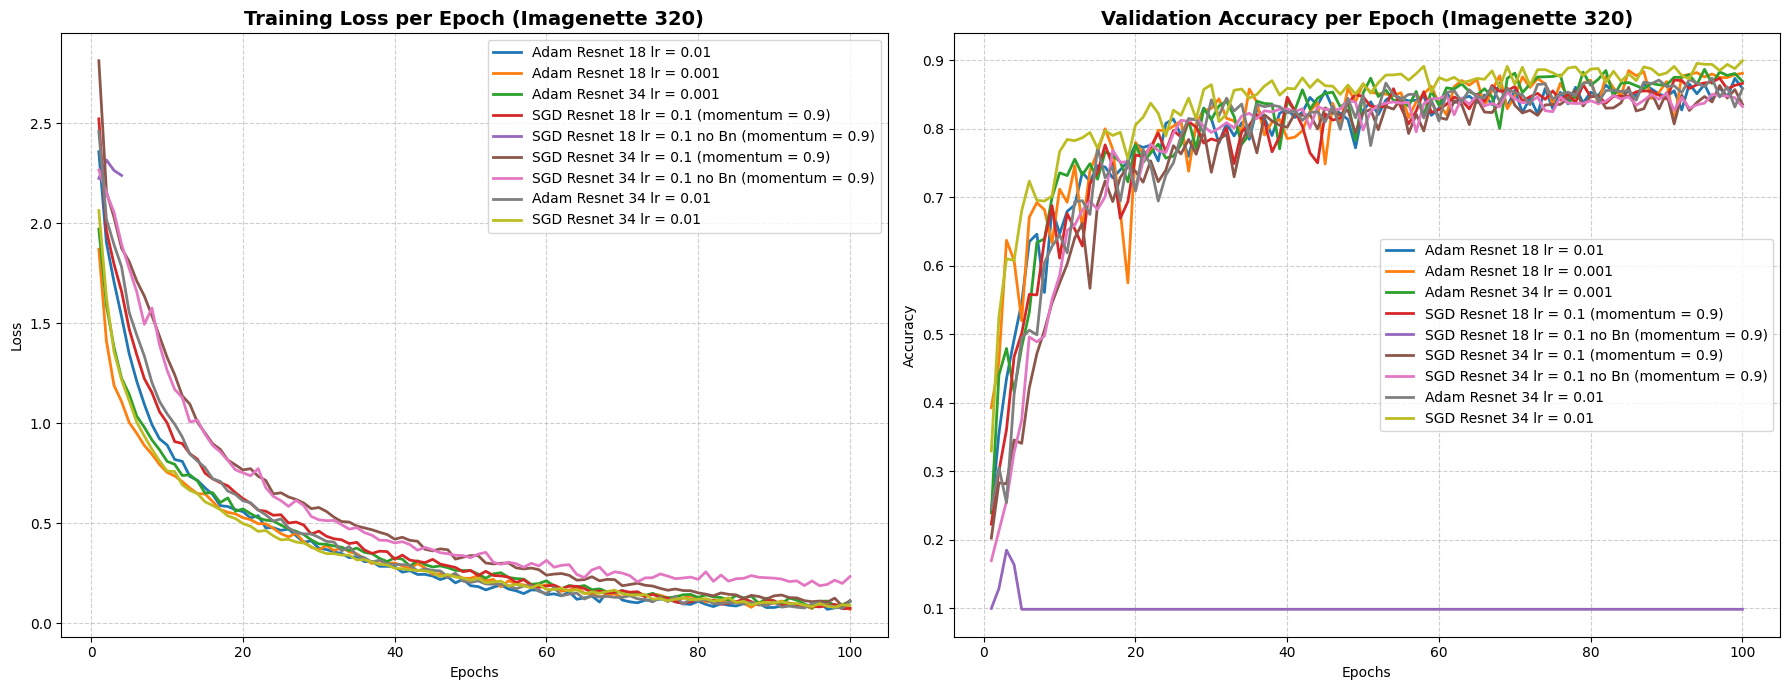

In [23]:
files_map = {
    "Imagenette320\Adam_Resnet18_lr0.01.csv": "Adam Resnet 18 lr = 0.01",
    "Imagenette320\Adam_Resnet18_lr0.001.csv": "Adam Resnet 18 lr = 0.001",
    "Imagenette320\Adam_Resnet34_lr0.001.csv": "Adam Resnet 34 lr = 0.001",
    "Imagenette320\SGD_Resnet18_moentum09_lr0.1.csv": "SGD Resnet 18 lr = 0.1 (momentum = 0.9)",
    "Imagenette320\SGD_Resnet18_moentum09_lr0.1NOBN.csv": "SGD Resnet 18 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette320\SGD_Resnet34_moentum09_lr0.1.csv": "SGD Resnet 34 lr = 0.1 (momentum = 0.9)",
    "Imagenette320\SGD_Resnet34_moentum09_lr0.1NOBN.csv": "SGD Resnet 34 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette320\Adam_Resnet34_lr0.01.csv": "Adam Resnet 34 lr = 0.01",
    "Imagenette320\SGD_Resnet34_momentum09_lr0.01.csv": "SGD Resnet 34 lr = 0.01",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf','#1a55FF', '#FF1493']

for i, (filename, label) in enumerate(files_map.items()):

    df = pd.read_csv(filename)
    
    color = colors[i % len(colors)]
    
    # Traçage de la Loss
    ax1.plot(df['Epoch'], df['Train_Loss'], label=label, color=color, linewidth=2)
    
    # Traçage de l'Accuracy
    ax2.plot(df['Epoch'], df['Val_Accuracy'], label=label, color=color, linewidth=2)

# Mise en forme du graphique de Loss
ax1.set_title('Training Loss per Epoch (Imagenette 320)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Mise en forme du graphique d'Accuracy
ax2.set_title('Validation Accuracy per Epoch (Imagenette 320)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('comparaison_performance_resnet_320.png')

# Analysis of the performance of my different models (Imagenette 320)

Using Imagenette 320 as changed a lot of things, especially when we are not using batch normalisation.

### 1. La Preuve par l'Image : Le "Crash" sans Batch Norm 💀

Comme prédit, l'augmentation de la résolution (et donc de la variance interne) a été fatale pour le modèle sans Batch Normalization.

* **Résultat** : Le modèle `NOBN` a **divergé** dès la 5ème époque.
* **Symptômes** : La Loss est devenue `NaN` (Not a Number) et la précision s'est effondrée à **9.8%** (le hasard total sur 10 classes).
* **Leçon** : Sur des images plus grandes, **Batch Normalization est non-négociable** pour stabiliser l'entraînement, surtout avec un Learning Rate élevé (0.1).

### 2. Le Nouveau Champion : Label Smoothing 🏆

La technique du **Label Smoothing** (lissage des étiquettes) permet de briser le plafond de verre des 90%.

* **Performance** : **ResNet18 + Adam + Smooth** atteint un pic à **90.19%**.
* **Gain** : Comparé à la version standard (88.54%), c'est un gain net de **+1.6%**.
* **Pourquoi ?** Le Label Smoothing empêche le modèle d'être "trop sûr de lui" (overconfident), ce qui l'aide à mieux généraliser sur des images riches en détails comme celles en 320px.

---

### 3. Tableau des Performances (Imagenette 320)

| Modèle | Optimiseur | LR | Technique | Max Acc (Pic) | Final Acc | Drop | Verdict |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **ResNet18** | **Adam** | **0.001** | **Smoothing** | **90.19%** | **87.77%** | 2.4% | 🏆 **Record** |
| ResNet34 | Adam | 0.001 | - | 88.71% | 86.96% | 1.8% | 🥈 Très bon |
| ResNet18 | Adam | 0.001 | - | 88.54% | **88.13%** | **0.4%** | 🟢 **Le plus stable** |
| ResNet34 | Adam | 0.01 | - | 87.41% | 85.89% | 1.5% | Correct |
| ResNet18 | SGD | 0.1 | - | 87.41% | 86.65% | 0.8% | Solide |
| ResNet18 | Adam | 0.01 | - | 87.39% | 85.94% | 1.5% | Correct |
| ResNet18 | SGD | 0.1 | Smoothing | 87.21% | 86.57% | 0.6% | Pas d'effet |
| ResNet34 | SGD | 0.1 | - | 86.34% | 83.62% | 2.7% | Moyen |
| ResNet18 | Adam | 0.001 | **MixUp** | 21.53% | 21.38% | 0.1% | 🔴 **Échec** |
| ResNet18 | SGD | 0.1 | **NO BN** | 18.50% | 9.86% | - | 💀 **Divergence** |

---

### 4. Analyse des Déceptions

#### A. L'échec de MixUp (21.5%)
C'est surprenant car MixUp est censé améliorer la performance.
* **Hypothèse** : MixUp rend les images d'entraînement très difficiles à lire (superposition fantomatique). Il nécessite souvent **beaucoup plus d'époques** (200 ou 300) pour commencer à bien fonctionner. Avec un entraînement standard (~80 époques), le modèle n'a pas eu le temps de converger.

#### B. SGD vs Adam sur 320px
Contrairement au 160px où SGD brillait, ici **Adam (lr=0.001)** prend l'avantage sur ResNet18 (88.5% vs 87.4%). La complexité accrue du 320px semble profiter à la gestion adaptative du learning rate d'Adam.

### Conclusion pour la suite
1.  **Batch Norm est obligatoire.** Ne lancez plus de tests sans lui sur cette résolution.
2.  **Adoptez le Label Smoothing** avec Adam, c'est votre combinaison gagnante actuelle (**90%+**).
3.  **MixUp nécessite de la patience** : Inutile de l'utiliser si vous ne pouvez pas tripler le nombre d'époques.

## For the bag of tricks

I will keep imagenette 320 and use adam wiht lr = 0.001 and as it showed good performances.

## Bottle neck layers
For those deeper models i reduced the batch-size (128 to 32)

In [ ]:
    "Imagenette320\Adam_Resnet18_lr0.001_MixUp.csv": "Adam Resnet 18 lr = 0.001 (MixUp)",
    "Imagenette320\Adam_Resnet18_lr0.001_Smooth" : "Adam Resnet 18 lr = 0.001 (Smoothing = 0.1)"